<a href="https://colab.research.google.com/github/faisalkhan4k/RoomMind/blob/main/notebooks/RoomMind_SmolVLM2_Finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 RoomMind – SmolVLM2-500M Fine-Tuning

**Goal:** Fine-tune `SmolVLM2-500M-Instruct` (the Student) on interior room images labelled by `Qwen2.5-VL-3B` (the Teacher), so the small model can extract structured furniture JSON on-device.

**Dataset:** `mohammedfaisalkhan4000/RoomMind-Interior-Labels`  
**Output schema:** `{"items": [{"name": "...", "style": "...", "price": <int>}]}`

---
**Recommended runtime:** `A100 GPU` (Runtime → Change runtime type → A100)  
Works on T4 too — just set `BATCH_SIZE = 1` in Cell 3.

## Cell 1 — Install dependencies

In [8]:
# ── INSTALL EVERYTHING (run this first, then Runtime → Restart Session) ──────
import subprocess, sys

pkgs = [
    "transformers>=4.44.0",
    "datasets>=2.20.0",
    "accelerate>=0.30.0",
    "peft>=0.11.0",
    "trl>=0.9.0",
    "bitsandbytes>=0.43.0",
    "Pillow",
    "safetensors",
    "huggingface_hub",
    "num2words"
]

for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", pkg], check=True)

print("✅ All packages installed — NOW RESTART THE RUNTIME before continuing")
print("   Runtime → Restart session  (or Ctrl+M .)")

✅ All packages installed — NOW RESTART THE RUNTIME before continuing
   Runtime → Restart session  (or Ctrl+M .)


In [6]:
# ── ALL IMPORTS ───────────────────────────────────────────────────────────────
import json, os, re, torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from PIL import Image
from datasets import load_dataset
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, TaskType, get_peft_model

# ── Sanity checks ─────────────────────────────────────────────────────────────
import transformers, peft, datasets, accelerate
print(f"transformers : {transformers.__version__}")
print(f"peft         : {peft.__version__}")
print(f"datasets     : {datasets.__version__}")
print(f"accelerate   : {accelerate.__version__}")
print(f"torch        : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# Confirm the problematic import specifically
from transformers import AutoModelForImageTextToText
print("✅ AutoModelForVision2Seq import OK")

transformers : 5.8.0
peft         : 0.19.1
datasets     : 4.8.5
accelerate   : 1.13.0
torch        : 2.10.0+cu128
CUDA         : True | Tesla T4
✅ AutoModelForVision2Seq import OK


## Cell 2 — Imports & GPU check

In [7]:
import json, os, re, torch
from dataclasses import dataclass, field
from typing import List, Optional

from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from PIL import Image
from transformers import (
    AutoProcessor, AutoModelForImageTextToText,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from torch.utils.data import Dataset

# GPU info
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU: {gpu}  |  VRAM: {vram:.1f} GB")
else:
    print("⚠️  No GPU found — switch runtime to GPU before continuing!")

✅ GPU: Tesla T4  |  VRAM: 15.6 GB


## Cell 3 — Configuration (edit here)

In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║           EDIT THESE VALUES TO CUSTOMISE YOUR RUN        ║
# ╚══════════════════════════════════════════════════════════╝

MODEL_ID       = "HuggingFaceTB/SmolVLM2-500M-Instruct"
DATASET_ID     = "mohammedfaisalkhan4000/RoomMind-Interior-Labels"
OUTPUT_DIR     = "/content/roommind-smolvlm2"   # saved to Colab disk

# ── LoRA ──────────────────────────────────────────────────
LORA_R         = 16      # adapter rank  (try 32 if loss doesn't drop)
LORA_ALPHA     = 32      # scaling factor (keep = 2 × LORA_R)
LORA_DROPOUT   = 0.05

# ── Training ──────────────────────────────────────────────
EPOCHS         = 3
BATCH_SIZE     = 1       # per device  (use 1 on T4)
GRAD_ACCUM     = 8       # effective batch = BATCH_SIZE × GRAD_ACCUM = 16
LEARNING_RATE  = 2e-4
VAL_SPLIT      = 0.1     # 10 % held out for evaluation
MAX_NEW_TOKENS = 512
USE_BF16       = False    # set False on T4 (use fp16=True instead)

# ── Debug mode ────────────────────────────────────────────
DEBUG          = False   # set True for a quick 50-sample smoke-test

print("✅ Config ready")

✅ Config ready


## Cell 4 — Load & inspect dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total rows: 1000
Columns   : ['image', 'label']

── Sample label (truncated) ──
```json
{
  "items": [
    {
      "name": "Sofa",
      "style": "Modern",
      "price": 1200
    },
    {
      "name": "Coffee Table",
      "style": "Contemporary",
      "price": 500
    },
    {
      "name": "Chair",
      "style": "Minimalist",
      "price": 300
    },
    {
      "name": 


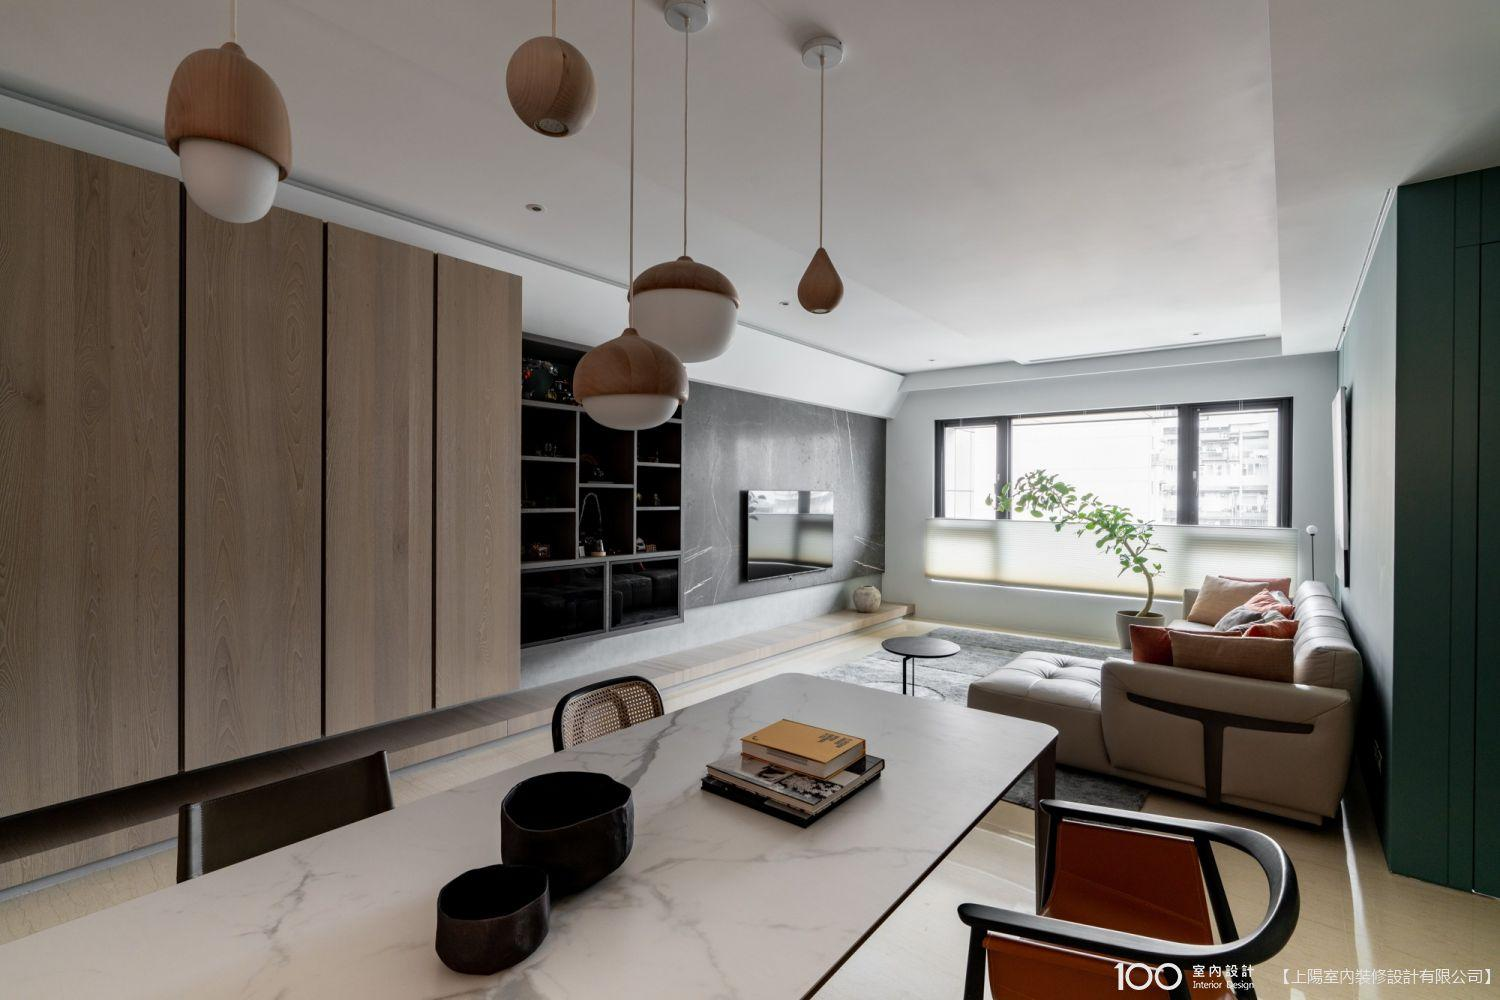

In [9]:
raw = load_dataset(DATASET_ID, split="train")

if DEBUG:
    raw = raw.select(range(50))
    print("🐞 Debug mode: using 50 samples")

print(f"Total rows: {len(raw)}")
print(f"Columns   : {raw.column_names}")
print()

# Preview first example
ex = raw[0]
print("── Sample label (truncated) ──")
print(str(ex['label'])[:300])
ex['image']

## Cell 5 — Helper functions

In [10]:
SYSTEM_PROMPT = (
    "You are RoomMind, an expert interior-design AI. "
    "When shown a photo of a room, you identify every visible piece of "
    "furniture or décor and return ONLY a valid JSON object in this exact "
    'schema: {"items": [{"name": "...", "style": "...", "price": <int>}]}. '
    "Do not output any explanation or markdown fences."
)
USER_PROMPT = (
    "Analyse this room photo and return the structured JSON listing "
    "every furniture item, its design style, and an estimated USD price."
)

def clean_label(raw: str) -> str:
    """Strip markdown fences the teacher model sometimes adds."""
    text = raw.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def is_valid_label(text: str) -> bool:
    try:
        obj = json.loads(text)
        return isinstance(obj, dict) and "items" in obj
    except Exception:
        return False

# Quick validation scan
valid = sum(1 for ex in raw if is_valid_label(clean_label(str(ex['label']))))
print(f"Valid JSON labels: {valid} / {len(raw)}  ({100*valid/len(raw):.1f}%)")

Valid JSON labels: 982 / 1000  (98.2%)


## Cell 6 — Load processor & model

In [31]:
print(f"Loading: {MODEL_ID}")

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token


model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,

    device_map="auto",
    trust_remote_code=True,
)
model = model.to(torch.float16)

model.config.use_cache = False

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"✅ Model loaded  |  Total params: {total_params:.0f}M")

Loading: HuggingFaceTB/SmolVLM2-500M-Instruct


[transformers] Current model requires 256 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

✅ Model loaded  |  Total params: 507M


## Cell 7 — Apply LoRA

In [7]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [26]:
from peft import LoraConfig, TaskType, get_peft_model


# Standard "Sweet Spot" Hyperparameters for LoRA
LORA_R = 16            # The 'Rank' - 16 or 32 is perfect for a 250M model
LORA_ALPHA = 32        # Usually 2x the Rank for scaling
LORA_DROPOUT = 0.05    # Prevents overfitting to your 1,000 images


lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    inference_mode=False,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 9,568,256 || all params: 517,050,560 || trainable%: 1.8505


## Cell 8 — Dataset class

In [27]:
class RoomMindDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = [
            ex for ex in hf_dataset
            if is_valid_label(clean_label(str(ex['label'])))
        ]
        print(f"  Valid samples: {len(self.data)} / {len(hf_dataset)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        image = ex['image'].convert("RGB")
        target_json = clean_label(str(ex['label']))

        messages = [
            {"role": "system",
             "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {"role": "user",
             "content": [{"type": "image"},
                         {"type": "text", "text": USER_PROMPT}]},
            {"role": "assistant",
             "content": [{"type": "text", "text": target_json}]},
        ]

        prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        inputs = processor(
            text=prompt,
            images=[image],
            return_tensors="pt",
            processor_kwargs={"truncation": True, "max_length": 2048},
        )
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        input_ids = inputs["input_ids"]
        labels = input_ids.clone()
        header_ids = processor.tokenizer(
            "<|im_start|>assistant\n", add_special_tokens=False
        ).input_ids
        h_len = len(header_ids)
        header_t = torch.tensor(header_ids)
        mask_until = 0
        for start in range(len(input_ids) - h_len, -1, -1):
            if torch.equal(input_ids[start: start + h_len], header_t):
                mask_until = start + h_len
                break
        labels[:mask_until] = -100
        inputs["labels"] = labels
        return inputs


class RoomMindCollator:
    def __init__(self):
        self.pad_id = processor.tokenizer.pad_token_id or 0

    def __call__(self, features):
        max_len = max(f["input_ids"].shape[0] for f in features)
        batch = {"input_ids": [], "attention_mask": [], "labels": []}
        pv, pam = [], []
        for f in features:
            p = max_len - f["input_ids"].shape[0]
            batch["input_ids"].append(F.pad(f["input_ids"], (0, p), value=self.pad_id))
            batch["attention_mask"].append(F.pad(f["attention_mask"], (0, p), value=0))
            batch["labels"].append(F.pad(f["labels"], (0, p), value=-100))
            if "pixel_values" in f: pv.append(f["pixel_values"])
            if "pixel_attention_mask" in f: pam.append(f["pixel_attention_mask"])
        batch = {k: torch.stack(v) for k, v in batch.items()}
        if pv:  batch["pixel_values"] = torch.stack(pv)
        if pam: batch["pixel_attention_mask"] = torch.stack(pam)
        return batch

print("✅ RoomMindDataset and RoomMindCollator defined")

✅ RoomMindDataset and RoomMindCollator defined


## Cell 9 — Build train / eval splits

In [28]:
splits = raw.train_test_split(test_size=VAL_SPLIT, seed=42)

print("Building train dataset …")
train_dataset = RoomMindDataset(splits["train"])
print("Building eval dataset …")
eval_dataset  = RoomMindDataset(splits["test"])

print(f"\n✅ Train: {len(train_dataset)} samples | Eval: {len(eval_dataset)} samples")

Building train dataset …
  Valid samples: 886 / 900
Building eval dataset …
  Valid samples: 96 / 100

✅ Train: 886 samples | Eval: 96 samples


## Cell 10 — Train

In [33]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1 if DEBUG else EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.05,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    bf16= False,
    fp16= True,
    dataloader_num_workers=2,
    save_total_limit=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    remove_unused_columns=False,
    logging_steps=10,
    logging_first_step=True,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=RoomMindCollator(),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Starting training …")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 11.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.41 GiB is allocated by PyTorch, and 7.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Cell 11 — Save model

In [ ]:
SAVE_DIR = os.path.join(OUTPUT_DIR, "final")
trainer.save_model(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)
print(f"✅ Model saved to {SAVE_DIR}")

## Cell 12 — Inference test on an eval image

In [ ]:
model.eval()
device = next(model.parameters()).device

# Pick a sample from the eval split
sample = splits["test"][0]
test_image = sample['image']
if not isinstance(test_image, Image.Image):
    test_image = Image.fromarray(test_image)
test_image = test_image.convert("RGB")

# Show the image
display(test_image.resize((400, 300)))

# Run inference
messages = [
    {"role": "system",
     "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
    {"role": "user",
     "content": [{"type": "image"},
                 {"type": "text", "text": USER_PROMPT}]},
]
prompt = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
inputs = processor(text=prompt, images=[test_image], return_tensors="pt").to(device)

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
    )

raw_output = processor.tokenizer.decode(
    out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
).strip()

print("\n── Ground truth ──────────────────────────────────")
print(clean_label(str(sample['label'])))
print("\n── Model output ──────────────────────────────────")
print(raw_output)

# Parse check
try:
    parsed = json.loads(raw_output)
    print(f"\n✅ Valid JSON  |  {len(parsed.get('items', []))} items found")
except Exception:
    print("\n⚠️  Output is not valid JSON — may need more epochs or check label quality")

## Cell 13 — (Optional) Merge LoRA weights for mobile export

In [ ]:
# # Merges the LoRA deltas back into the base weights.
# # The resulting model is self-contained and ready for CoreML / ONNX conversion.

# MERGED_DIR = "/content/roommind-merged"

# print("Merging LoRA adapters into base weights …")
# merged_model = model.merge_and_unload()
# merged_model.save_pretrained(MERGED_DIR)
# processor.save_pretrained(MERGED_DIR)
# print(f"✅ Merged model saved to {MERGED_DIR}")
# print("   Next step: upload to HuggingFace Hub or convert to CoreML/ONNX for mobile.")

## Cell 14 — (Optional) Push to HuggingFace Hub

In [ ]:
# Uncomment and fill in your HF token + repo name to push the merged model.

# from huggingface_hub import login
# login(token="hf_YOUR_TOKEN_HERE")

# HF_REPO = "your-username/RoomMind-SmolVLM2-500M"
# merged_model.push_to_hub(HF_REPO)
# processor.push_to_hub(HF_REPO)
# print(f"✅ Pushed to https://huggingface.co/{HF_REPO}")